# MORE Dataset: Precipitation IDF Risk Maps for Italy
## MOloch-downscaled ERA5 REanalysis (1991–2020) — Return Period Analysis

**Dataset:** [Zenodo 10.5281/zenodo.18470948](https://doi.org/10.5281/zenodo.18470948)  
**Spatial resolution:** ~1.7 km | **Temporal resolution:** hourly  
**Variable:** `moloch_tp_*` — total precipitation  
**Goal:** IDF (Intensity–Duration–Frequency) maps for RP = 5, 10, 25, 50, 100 years  
**Durations:** 1h, 3h, 6h, 12h, 24h

## 1. Imports & configuration

In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import from_levels_and_colors
from scipy.stats import genextreme, ks_1samp
from tqdm.auto import tqdm

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print('cartopy not found – maps will use plain imshow')

print('All imports OK')

All imports OK


In [2]:
# ── USER SETTINGS ─────────────────────────────────────────────────────────────

# Root folder that contains all more_YYYY.tar.gz and the extracted more_YYYY/ folders
# DATA_ROOT = r"/home/admin_climatecharted_com/data/MOloch"
DATA_ROOT = r"/mnt/data/more"

202022
# Where to write output NetCDF and PNG files
OUTPUT_DIR = os.path.join('/home/admin_climatecharted_com/data/MOloch', 'IDF_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Years available in the dataset
YEARS = list(range(1991, 2021))          # 1991–2020

# Precipitation variable name inside each NetCDF
TP_VAR = 'tp'                            # adjust if ncdump reveals a different name

# Accumulation durations (hours)
DURATIONS = [1, 3, 6, 12, 24]

# Return periods (years)
RETURN_PERIODS = np.array([5, 10, 25, 50, 100])

# Single test file
TEST_FILE = os.path.join(
    DATA_ROOT, 'more_2020', '2020', 'moloch_tp_202005_zip_masked.nc'
)

# ──────────────────────────────────────────────────────────────────────────────

## 2. Dataset inspection — single file

In [3]:
# ── 2.1 Open and display structure ────────────────────────────────────────────
ds_test = xr.open_dataset(TEST_FILE)
print(ds_test)
ds_test

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 744, lat: 960, lon: 768)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-05-01 ... 2020-05-31T23:00:00
  * lat      (lat) float64 8kB 35.72 35.74 35.75 35.76 ... 49.25 49.27 49.28
  * lon      (lon) float64 6kB 4.02 4.041 4.061 4.082 ... 19.63 19.65 19.67
Data variables:
    tp       (time, lat, lon) float32 2GB ...
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue May 13 10:47:55 2025: cdo ifthen ita_mask_moria_def_no_...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...


<xarray.Dataset> Size: 2GB
Dimensions:  (time: 744, lat: 960, lon: 768)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-05-01 ... 2020-05-31T23:00:00
  * lat      (lat) float64 8kB 35.72 35.74 35.75 35.76 ... 49.25 49.27 49.28
  * lon      (lon) float64 6kB 4.02 4.041 4.061 4.082 ... 19.63 19.65 19.67
Data variables:
    tp       (time, lat, lon) float32 2GB ...
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue May 13 10:47:55 2025: cdo ifthen ita_mask_moria_def_no_...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [4]:
# ── 2.2 Variable names, dimensions, units ─────────────────────────────────────
print('=== VARIABLES ===')
for vname, var in ds_test.data_vars.items():
    print(f'  {vname:30s}  dims={var.dims}  dtype={var.dtype}  units={var.attrs.get("units", "?")}')

print('\n=== COORDINATES ===')
for cname, coord in ds_test.coords.items():
    print(f'  {cname:20s}  shape={coord.shape}')

print('\n=== GLOBAL ATTRIBUTES ===')
for k, v in ds_test.attrs.items():
    print(f'  {k}: {v}')

=== VARIABLES ===
  tp                              dims=('time', 'lat', 'lon')  dtype=float32  units=kg m**-2

=== COORDINATES ===
  time                  shape=(744,)
  lon                   shape=(768,)
  lat                   shape=(960,)

=== GLOBAL ATTRIBUTES ===
  CDI: Climate Data Interface version 2.1.1 (https://mpimet.mpg.de/cdi)
  Conventions: CF-1.6
  history: Tue May 13 10:47:55 2025: cdo ifthen ita_mask_moria_def_no_cornice.nc 2020/moloch_tp_202005_zip.nc 2020/moloch_tp_202005_zip_masked.nc
Mon Mar 31 13:31:20 2025: cdo selvar,tp /mnt/Moria/202005/moloch_2020-05_zip.nc /mnt/Moria/INTERROGATION/moloch_tp_202005_zip.nc
Sat Mar 22 18:42:37 2025: cdo -f nc4c -z zip_6 copy /ec/res4/scratch/cc00/moria/output/NetCDF/202005/moloch_cat.nc /ec/res4/scratch/cc00/moria/output/NetCDF/202005/moloch_2020-05_zip.nc
Sat Mar 22 18:25:09 2025: cdo settaxis,2020-05-01,00:00,1hour /ec/res4/scratch/cc00/moria/output/NetCDF/202005/cat_tmp.nc /ec/res4/scratch/cc00/moria/output/NetCDF/202005/molo

In [5]:
# ── 2.3 Detect the actual precipitation variable name ─────────────────────────
# MORE v1 uses 'tp' but let's be safe
candidates = [v for v in ds_test.data_vars if 'tp' in v.lower() or 'prec' in v.lower() or 'rain' in v.lower()]
if candidates:
    TP_VAR = candidates[0]
    print(f'Using precipitation variable: "{TP_VAR}"')
else:
    print('Could not auto-detect variable; using TP_VAR =', TP_VAR)
    print('Available vars:', list(ds_test.data_vars))

Using precipitation variable: "tp"


In [6]:
# ── 2.4 Time axis ─────────────────────────────────────────────────────────────
times = ds_test.time.values
print(f'Time steps : {len(times)}')
print(f'Start      : {times[0]}')
print(f'End        : {times[-1]}')
if len(times) > 1:
    dt_hours = (times[1] - times[0]) / np.timedelta64(1, 'h')
    print(f'Time step  : {dt_hours:.1f} h')

Time steps : 744
Start      : 2020-05-01T00:00:00.000000000
End        : 2020-05-31T23:00:00.000000000
Time step  : 1.0 h


In [7]:
# ── 2.5 Spatial coverage ──────────────────────────────────────────────────────
lat = ds_test['lat'].values if 'lat' in ds_test.coords else ds_test['latitude'].values
lon = ds_test['lon'].values if 'lon' in ds_test.coords else ds_test['longitude'].values

print(f'Lat range  : {lat.min():.3f} – {lat.max():.3f}')
print(f'Lon range  : {lon.min():.3f} – {lon.max():.3f}')
print(f'Grid shape : {lat.shape}')

Lat range  : 35.721 – 49.281
Lon range  : 4.020 – 19.667
Grid shape : (960,)


In [8]:
# ── 2.6 Basic statistics on precipitation ─────────────────────────────────────
da_tp = ds_test[TP_VAR].isel(time=slice(0, 24))   # first day only for speed
print('Shape (time, lat, lon):', da_tp.shape)
print('Min  :', float(da_tp.min()))
print('Max  :', float(da_tp.max()))
print('Mean :', float(da_tp.mean()))
print('Units:', da_tp.attrs.get('units', 'unknown'))

Shape (time, lat, lon): (24, 960, 768)
Min  : 0.0
Max  : 42.8369140625
Mean : 0.06813608855009079
Units: kg m**-2


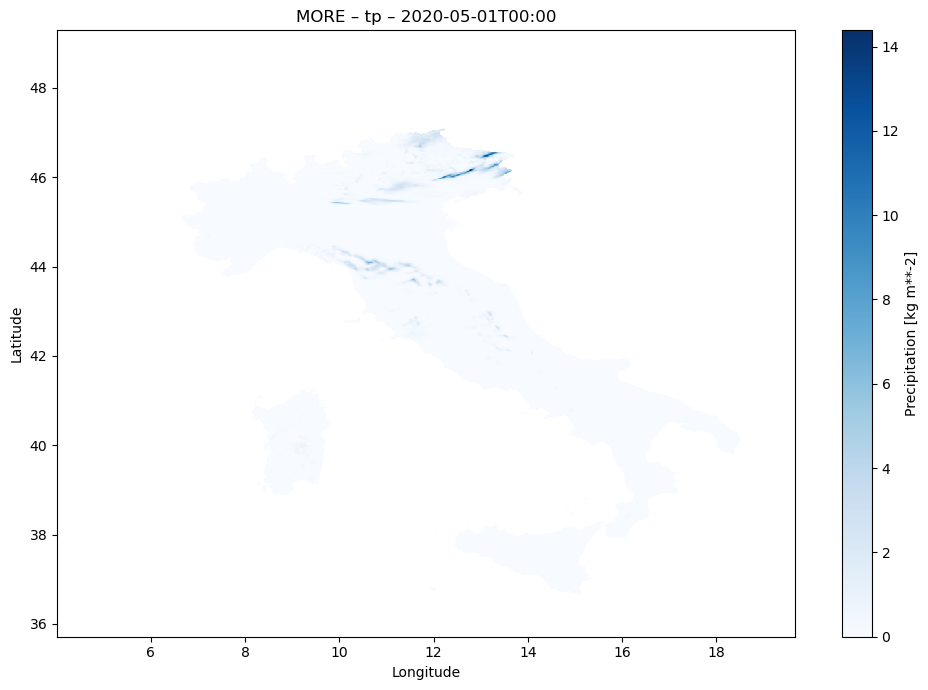

Snapshot saved.


In [9]:
# ── 2.7 Quick map — first time step ───────────────────────────────────────────
da_snap = ds_test[TP_VAR].isel(time=0)

# Squeeze any extra singleton dimensions (height, depth, etc.)
da_snap = da_snap.squeeze()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.pcolormesh(lon, lat, da_snap.values, cmap='Blues', vmin=0)
plt.colorbar(im, ax=ax, label=f'Precipitation [{da_tp.attrs.get("units", "mm")}]')
ax.set_title(f'MORE – {TP_VAR} – {str(times[0])[:16]}')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'snapshot_202005_t0.png'), dpi=150)
plt.show()
print('Snapshot saved.')

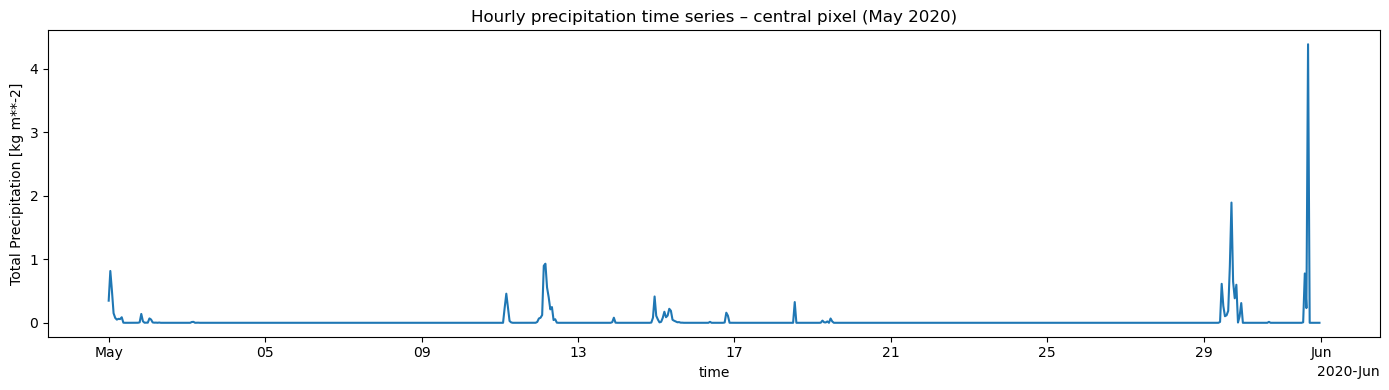

In [10]:
# ── 2.8 Time series at a central pixel ────────────────────────────────────────
mid_lat_idx = lat.shape[0] // 2
mid_lon_idx = lat.shape[1] // 2 if lat.ndim == 2 else lon.shape[0] // 2

if lat.ndim == 2:
    ts = ds_test[TP_VAR].isel(lat=mid_lat_idx, lon=mid_lon_idx).squeeze()
else:
    ts = ds_test[TP_VAR].isel(lat=mid_lat_idx, lon=mid_lon_idx).squeeze()

fig, ax = plt.subplots(figsize=(14, 4))
ts.plot(ax=ax)
ax.set_title('Hourly precipitation time series – central pixel (May 2020)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'timeseries_central_pixel_202005.png'), dpi=150)
plt.show()

In [11]:
# ── 2.9 Check for accumulation type (hourly vs. cumulative from run start) ────
# If values are monotonically increasing within a day, tp is cumulative;
# if mostly near-zero with occasional spikes, it is already hourly amounts.
sample = ds_test[TP_VAR].isel(lat=mid_lat_idx, lon=mid_lon_idx).squeeze().values
diff = np.diff(sample[:48])
n_negative = (diff < -0.01).sum()
print(f'Negative differences in first 48 h: {n_negative}')
if n_negative > 5:
    print('→ Variable appears to be HOURLY AMOUNTS (or de-accumulated).  No further processing needed.')
    DEACCUMULATE = False
else:
    print('→ Variable may be CUMULATIVE from run start. De-accumulation will be applied per month.')
    DEACCUMULATE = True

ds_test.close()

Negative differences in first 48 h: 9
→ Variable appears to be HOURLY AMOUNTS (or de-accumulated).  No further processing needed.


## 3. Helper functions

In [12]:
def deaccumulate(da):
    """
    Convert a cumulative-from-run-start precipitation array to hourly amounts.
    Assumes data is already in monthly files where accumulation resets each month.
    Negative differences (forecast resets) are set to zero.
    """
    arr = da.values.copy().astype(np.float32)
    arr_diff = np.diff(arr, axis=0, prepend=arr[[0]])
    arr_diff[arr_diff < 0] = arr[arr_diff < 0]  # first step of each reset
    arr_diff[arr_diff < 0] = 0                  # still negative → zero
    return da.copy(data=arr_diff)


def load_hourly_tp_year(year, data_root, tp_var, deacc=False):
    """
    Load all monthly TP files for a given year and concatenate along time.
    Returns an xarray.DataArray with hourly precipitation amounts [mm/h].
    """
    pattern = os.path.join(
        data_root, f'more_{year}', str(year),
        f'moloch_tp_{year}??_zip_masked.nc'
    )
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files found for year {year}:\n  {pattern}')

    monthly = []
    for f in files:
        ds = xr.open_dataset(f)
        da = ds[tp_var].squeeze()   # drop height/depth if present
        if deacc:
            da = deaccumulate(da)
        monthly.append(da)
        ds.close()

    return xr.concat(monthly, dim='time')


def rolling_accumulation_annual_max(da_year, duration_h):
    """
    Compute the annual maximum of rolling-sum precipitation for a given duration.
    Returns a 2-D DataArray (lat x lon) with the annual maximum [mm].
    """
    rolled = da_year.rolling(time=duration_h, min_periods=duration_h).sum()
    return rolled.max(dim='time')


print('Helper functions defined.')

Helper functions defined.


In [13]:
def fit_gev_pixel(ts):
    """
    Fit a GEV distribution to a 1-D array (annual maxima for one pixel).
    Returns (shape, loc, scale) or NaN-tuple if fitting fails.
    """
    valid = ts[~np.isnan(ts)]
    if len(valid) < 5 or valid.max() == 0:
        return (np.nan, np.nan, np.nan)
    try:
        params = genextreme.fit(valid)
        return params          # (shape, loc, scale)
    except Exception:
        return (np.nan, np.nan, np.nan)


def gev_return_value(params, return_period):
    """
    Compute the GEV return value for a given return period.
    params : (shape, loc, scale) from scipy genextreme.fit
    """
    shape, loc, scale = params
    if np.isnan(shape):
        return np.nan
    p_exceed = 1.0 / return_period          # exceedance probability
    return genextreme.ppf(1 - p_exceed, shape, loc=loc, scale=scale)


def fit_and_compute_rp(annual_max_stack, return_periods):
    """
    Apply GEV fitting and return-value calculation over a full spatial grid.

    Parameters
    ----------
    annual_max_stack : np.ndarray, shape (n_years, n_lat, n_lon)
    return_periods   : 1-D array of return periods in years

    Returns
    -------
    rv : np.ndarray, shape (n_rp, n_lat, n_lon)  – return values [mm]
    """
    n_years, n_lat, n_lon = annual_max_stack.shape
    n_rp = len(return_periods)
    rv = np.full((n_rp, n_lat, n_lon), np.nan, dtype=np.float32)

    for i in tqdm(range(n_lat), desc='  GEV fitting rows'):
        for j in range(n_lon):
            ts = annual_max_stack[:, i, j]
            params = fit_gev_pixel(ts)
            for k, rp in enumerate(return_periods):
                rv[k, i, j] = gev_return_value(params, rp)
    return rv


print('GEV fitting functions defined.')

GEV fitting functions defined.


## 4. Build annual-maximum stacks for each duration

This is the most time-consuming step.  
For 30 years × 5 durations on a ~768×960 grid expect **several hours** on a workstation.  
A progress bar is shown for each year. Intermediate results are saved so the loop can be restarted.

In [14]:
import resource, os

def peak_rss_gb():
    kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return kb / 1e6  # Linux reports in kB

TEST_YEAR = 2020
TEST_DUR  = 1   # hours

print(f"RSS before load: {peak_rss_gb():.2f} GB")
da_test_year = load_hourly_tp_year(TEST_YEAR, DATA_ROOT, TP_VAR, deacc=DEACCUMULATE)
print(f"RSS after load:  {peak_rss_gb():.2f} GB")
ann_max_test = rolling_accumulation_annual_max(da_test_year, TEST_DUR)
print(f"RSS after roll:  {peak_rss_gb():.2f} GB")

RSS before load: 0.63 GB


RSS after load:  75.84 GB
RSS after roll:  190.14 GB


In [15]:
import xarray as xr, os
f = os.path.join(DATA_ROOT, 'more_2020', '2020', 'moloch_tp_202005_zip_masked.nc')
ds = xr.open_dataset(f)
print(ds)
print()
da = ds['tp'].squeeze()
print('shape:', da.shape)
print('dtype:', da.dtype)
print('dims:', da.dims)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 744, lat: 960, lon: 768)
Coordinates:
  * time     (time) datetime64[ns] 6kB 2020-05-01 ... 2020-05-31T23:00:00
  * lat      (lat) float64 8kB 35.72 35.74 35.75 35.76 ... 49.25 49.27 49.28
  * lon      (lon) float64 6kB 4.02 4.041 4.061 4.082 ... 19.63 19.65 19.67
Data variables:
    tp       (time, lat, lon) float32 2GB ...
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue May 13 10:47:55 2025: cdo ifthen ita_mask_moria_def_no_...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

shape: (744, 960, 768)
dtype: float32
dims: ('time', 'lat', 'lon')


In [16]:
"""
Paste these cells into your notebook to replace cells 4.0 and 4.1.
"""

# ─────────────────────────────────────────────────────────────────────────────
# CELL A  –  load the helpers  (add after Section 3, run once)
# ─────────────────────────────────────────────────────────────────────────────

import sys, os
sys.path.insert(0, '/home/admin_climatecharted_com/GitHub/hazard-heavy-rain')
import idf_chunked_helpers as _h

rolling_accumulation_annual_max_chunked = _h.rolling_accumulation_annual_max_chunked
print('Chunked helpers loaded.')
print(f'Peak RAM per year ≈ 2 × 2.2 GB carry buffer = ~5 GB  (was ~190 GB)')

Chunked helpers loaded.
Peak RAM per year ≈ 2 × 2.2 GB carry buffer = ~5 GB  (was ~190 GB)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL B  –  smoke test  (replaces 4.0)
# ─────────────────────────────────────────────────────────────────────────────

import resource

def rss_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6

TEST_YEAR = 2020
TEST_DUR  = 1

print(f'RSS before: {rss_gb():.2f} GB')
ann_max_test = rolling_accumulation_annual_max_chunked(
    TEST_YEAR, DATA_ROOT, TP_VAR, TEST_DUR, deacc=DEACCUMULATE
)
print(f'RSS after:  {rss_gb():.2f} GB')
print(f'Shape    :  {ann_max_test.shape}')
print(f'Min/Max  :  {float(ann_max_test.min()):.2f} / {float(ann_max_test.max()):.2f} mm')
print('Smoke test PASSED.')

RSS before: 190.14 GB
RSS after:  190.14 GB
Shape    :  (960, 768)
Min/Max  :  4.41 / 134.49 mm
Smoke test PASSED.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL C  –  full build loop  (replaces 4.1)
# ─────────────────────────────────────────────────────────────────────────────

from tqdm.auto import tqdm

for dur in DURATIONS:
    out_path = os.path.join(OUTPUT_DIR, f'annmax_{dur}h.nc')
    if os.path.exists(out_path):
        print(f'  {dur}h – already exists, skipping.')
        continue

    print(f'\n──── Duration {dur}h ────')
    stacks = []

    for yr in tqdm(YEARS, desc=f'{dur}h annual max'):
        try:
            ann_max = rolling_accumulation_annual_max_chunked(
                yr, DATA_ROOT, TP_VAR, dur, deacc=DEACCUMULATE
            )
        except FileNotFoundError as e:
            print(f'  WARNING: {e} – skipping year {yr}')
            continue

        ann_max = ann_max.expand_dims(dim={'year': [yr]})
        stacks.append(ann_max)

    if not stacks:
        print(f'  No data for duration {dur}h – skipping.')
        continue

    ds_stack = xr.concat(stacks, dim='year')   # 30 × 2D slices ≈ 85 MB – fine
    ds_stack.name = f'annmax_tp_{dur}h'
    ds_stack.attrs['units']       = 'mm'
    ds_stack.attrs['description'] = f'Annual maximum {dur}h precipitation (MORE dataset)'
    ds_stack.to_dataset(name=f'annmax_tp_{dur}h').to_netcdf(out_path)
    print(f'  Saved → {out_path}')

  3h – already exists, skipping.
  6h – already exists, skipping.

──── Duration 12h ────


12h annual max:  33%|███▎      | 10/30 [43:35<1:32:16, 276.84s/it]

## 5. GEV fitting and return-value computation

In [ ]:
# ── 5.1 Compute IDF return-value maps for all durations × return periods ───────
# Output files: <OUTPUT_DIR>/idf_<dur>h.nc
DURATIONS = [1, 3, 6, 12, 24]

for dur in DURATIONS:
    in_path  = os.path.join(OUTPUT_DIR, f'annmax_{dur}h.nc')
    out_path = os.path.join(OUTPUT_DIR, f'idf_{dur}h.nc')

    if not os.path.exists(in_path):
        print(f'  {dur}h – annual max file missing, skipping.')
        continue
    if os.path.exists(out_path):
        print(f'  {dur}h – IDF file already exists, skipping.')
        continue

    print(f'\n──── GEV fitting for {dur}h ────')
    ds_am = xr.open_dataset(in_path)
    varname = f'annmax_tp_{dur}h'
    stack = ds_am[varname].values          # shape: (n_years, n_lat, n_lon)

    rv = fit_and_compute_rp(stack, RETURN_PERIODS)  # (n_rp, n_lat, n_lon)

    # Build output dataset
    lat_coord = ds_am['lat'] if 'lat' in ds_am.coords else ds_am['latitude']
    lon_coord = ds_am['lon'] if 'lon' in ds_am.coords else ds_am['longitude']

    ds_idf = xr.Dataset(
        {'return_value': (['return_period', 'lat', 'lon'],
                          rv,
                          {'units': 'mm', 'long_name': f'{dur}h precipitation return value'})},
        coords={
            'return_period': RETURN_PERIODS,
            'lat': lat_coord,
            'lon': lon_coord,
        },
        attrs={
            'duration_h': dur,
            'distribution': 'GEV (scipy genextreme)',
            'source': 'MORE v1.0 – 1991-2020 hourly precipitation',
        }
    )
    ds_idf.to_netcdf(out_path)
    print(f'  Saved → {out_path}')
    ds_am.close()

## 6. Plot return-period maps

In [ ]:
# ── 6.1 Color scale helper ─────────────────────────────────────────────────────

def make_precip_cmap():
    levels = [5, 10, 15, 20, 25, 30, 40, 50, 60, 80, 100, 130, 160, 200]
    colors = [
        '#ffffff', '#d6e2ff', '#8db2ff', '#626ff7', '#0062ff',
        '#019696', '#01c634', '#63ff01', '#c6ff34', '#ffff02',
        '#ffc601', '#ffa001', '#ff7c00', '#ff1901', '#a20a28',
        '#9b159d', '#d294d3',
    ]
    cmap, norm = from_levels_and_colors(levels, colors, extend='max')
    return cmap, norm, levels

PRECIP_CMAP, PRECIP_NORM, PRECIP_LEVELS = make_precip_cmap()
print('Color scale ready.')

In [ ]:
# ── 6.2 Plot all (duration × return period) combinations ─────────────────────

for dur in DURATIONS:
    idf_path = os.path.join(OUTPUT_DIR, f'idf_{dur}h.nc')
    if not os.path.exists(idf_path):
        print(f'  {dur}h IDF file not found – skipping plots.')
        continue

    ds_idf = xr.open_dataset(idf_path)
    lat_v  = ds_idf['lat'].values
    lon_v  = ds_idf['lon'].values

    # One figure per duration, one subplot per return period
    n_rp  = len(RETURN_PERIODS)
    ncols = min(n_rp, 5)
    nrows = (n_rp + ncols - 1) // ncols

    if HAS_CARTOPY:
        proj   = ccrs.PlateCarree()
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(5 * ncols, 5 * nrows),
            subplot_kw={'projection': proj},
            constrained_layout=True
        )
    else:
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(5 * ncols, 5 * nrows),
            constrained_layout=True
        )

    axes_flat = np.array(axes).flatten()
    fig.suptitle(f'Precipitation return values – {dur}h duration (MORE 1991–2020)', fontsize=14)

    for k, rp in enumerate(RETURN_PERIODS):
        ax = axes_flat[k]
        rv_map = ds_idf['return_value'].sel(return_period=rp).values

        if HAS_CARTOPY:
            im = ax.pcolormesh(
                lon_v, lat_v, rv_map,
                cmap=PRECIP_CMAP, norm=PRECIP_NORM,
                transform=ccrs.PlateCarree()
            )
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
            ax.add_feature(cfeature.BORDERS, linewidth=0.4)
            ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', zorder=0)
            gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
            gl.top_labels = gl.right_labels = False
        else:
            im = ax.pcolormesh(lon_v, lat_v, rv_map, cmap=PRECIP_CMAP, norm=PRECIP_NORM)
            ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

        ax.set_title(f'RP = {rp} yr', fontsize=11)
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05,
                     label='mm', shrink=0.85)

    # Hide unused axes
    for k in range(len(RETURN_PERIODS), len(axes_flat)):
        axes_flat[k].set_visible(False)

    out_png = os.path.join(OUTPUT_DIR, f'IDF_maps_{dur}h.png')
    fig.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {out_png}')
    ds_idf.close()

## 7. IDF curves at a single point of interest

In [ ]:
# ── 7.1 Choose a point (edit lat/lon to any Italian location) ─────────────────
POINT_NAME = 'Milan'
POINT_LAT  = 45.46
POINT_LON  = 9.19

# Build IDF curve: precipitation [mm] vs return period for each duration
idf_table = {}   # {dur: {rp: value}}

for dur in DURATIONS:
    idf_path = os.path.join(OUTPUT_DIR, f'idf_{dur}h.nc')
    if not os.path.exists(idf_path):
        continue
    ds_idf = xr.open_dataset(idf_path)
    point_data = ds_idf['return_value'].sel(
        lat=POINT_LAT, lon=POINT_LON, method='nearest'
    ).values   # shape: (n_rp,)
    idf_table[dur] = dict(zip(RETURN_PERIODS.tolist(), point_data.tolist()))
    ds_idf.close()

# Print table
print(f'IDF table at {POINT_NAME} ({POINT_LAT}°N, {POINT_LON}°E)')
header = f'{'Duration':>10s}' + ''.join([f'{f"RP{rp}":>10s}' for rp in RETURN_PERIODS])
print(header)
print('─' * len(header))
for dur, rp_vals in idf_table.items():
    row = f'{str(dur)+"h":>10s}' + ''.join([f'{v:10.1f}' for v in rp_vals.values()])
    print(row)

In [ ]:
# ── 7.2 Plot IDF curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
markers = ['o', 's', '^', 'D', 'v']

for i, (dur, rp_vals) in enumerate(idf_table.items()):
    rps = list(rp_vals.keys())
    vals = list(rp_vals.values())
    ax.plot(rps, vals, marker=markers[i % len(markers)], label=f'{dur}h', linewidth=2)

ax.set_xscale('log')
ax.set_xticks(RETURN_PERIODS)
ax.set_xticklabels(RETURN_PERIODS)
ax.set_xlabel('Return Period (years)', fontsize=12)
ax.set_ylabel('Precipitation (mm)', fontsize=12)
ax.set_title(f'IDF Curves – {POINT_NAME} ({POINT_LAT}°N, {POINT_LON}°E)', fontsize=13)
ax.legend(title='Duration', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
out_idf_png = os.path.join(OUTPUT_DIR, f'IDF_curves_{POINT_NAME.replace(" ","_")}.png')
fig.savefig(out_idf_png, dpi=150)
plt.show()
print(f'IDF curves saved → {out_idf_png}')

## 8. Validation — GEV fit quality for one pixel

In [ ]:
# ── 8.1 Load 1h annual maxima for the point of interest ───────────────────────
dur_val = 1
am_path = os.path.join(OUTPUT_DIR, f'annmax_{dur_val}h.nc')

if os.path.exists(am_path):
    ds_am = xr.open_dataset(am_path)
    varname = f'annmax_tp_{dur_val}h'
    ts_point = ds_am[varname].sel(
        lat=POINT_LAT, lon=POINT_LON, method='nearest'
    ).values   # shape: (n_years,)

    params = genextreme.fit(ts_point[~np.isnan(ts_point)])
    shape, loc, scale = params
    print(f'GEV parameters for {POINT_NAME}, {dur_val}h:')
    print(f'  shape (ξ) = {shape:.4f}')
    print(f'  loc   (μ) = {loc:.4f} mm')
    print(f'  scale (σ) = {scale:.4f} mm')

    ks_stat, ks_p = ks_1samp(ts_point[~np.isnan(ts_point)], genextreme.cdf, args=params)
    print(f'\nKS test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}')
    print('Fit is', 'GOOD (p > 0.05)' if ks_p > 0.05 else 'POOR (p ≤ 0.05)')

    # Probability plot
    from scipy.stats import probplot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Q-Q plot
    (osm, osr), (slope, intercept, r) = probplot(ts_point[~np.isnan(ts_point)],
                                                  dist=genextreme, sparams=params)
    axes[0].plot(osm, osr, 'o', alpha=0.7)
    axes[0].plot([osm.min(), osm.max()],
                 [slope * osm.min() + intercept, slope * osm.max() + intercept], 'r-')
    axes[0].set_title('Q-Q plot'); axes[0].set_xlabel('Theoretical'); axes[0].set_ylabel('Observed')

    # Empirical vs. theoretical CDF
    x = np.linspace(ts_point[~np.isnan(ts_point)].min(),
                    ts_point[~np.isnan(ts_point)].max(), 200)
    axes[1].plot(x, genextreme.cdf(x, *params), 'r-', label='GEV CDF')
    axes[1].hist(ts_point[~np.isnan(ts_point)], density=True, cumulative=True,
                 bins=10, alpha=0.5, label='Empirical')
    axes[1].set_title('CDF'); axes[1].legend()

    # Annual max time series
    axes[2].bar(YEARS[:len(ts_point)], ts_point, color='steelblue', alpha=0.7)
    axes[2].set_title(f'Annual max {dur_val}h – {POINT_NAME}')
    axes[2].set_xlabel('Year'); axes[2].set_ylabel('mm')

    plt.suptitle(f'GEV validation – {dur_val}h – {POINT_NAME}', fontsize=12)
    plt.tight_layout()
    val_png = os.path.join(OUTPUT_DIR, f'GEV_validation_{POINT_NAME.replace(" ","_")}_{dur_val}h.png')
    fig.savefig(val_png, dpi=150)
    plt.show()
    print(f'Validation plot saved → {val_png}')
    ds_am.close()
else:
    print(f'Annual max file {am_path} not found – run Section 4 first.')

## 9. Summary of output files

In [ ]:
print(f'All outputs in: {OUTPUT_DIR}\n')
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {f:50s}  {size_mb:8.1f} MB')

---
## Notes

### De-accumulation
The MORE `tp` variable stores **hourly amounts** (each file is a monthly sequence of hourly totals).  
Section 2.9 auto-detects whether de-accumulation is needed and sets `DEACCUMULATE` accordingly.

### Units
MORE precipitation is stored in **mm** (millimetres per hour).  
The rolling sum over `duration_h` steps therefore yields **mm** totals directly.

### Performance tips
- Use `dask` (`xr.open_mfdataset(..., chunks={'time': 744})`) to parallelise the annual-max computation across months.
- For very large grids, `numba` or `joblib` can be used to parallelise the pixel-wise GEV loop.
- The intermediate `annmax_*.nc` files are small (~50–100 MB each) and allow restarting without reprocessing.

### Reference
CLIMAAX Hazard Assessment workflow:  
https://climaax.github.io/crabook-test/notebooks/workflows/HEAVY_RAINFALL/01_Extreme_precipitation/EXTREME_PRECIPITATION_Hazard_Assessment.html